# Lyapunov Exponents

We will develop a generic but basic test for detecting chaos in a known map/flow by relying on the largest Lyapunov exponent ($\lambda_1$) and bounded-ness of the solution, here considering the Hénon map first
$$\begin{align}X_{n+1} &= 1-aX_n^2+bY_n \\
Y_{n+1} &= X_n,\end{align}$$
with $a = 1.4$ and $b=0.3$.

In [68]:
import numpy as np
import matplotlib.pyplot as plt

In [69]:
def henon_map(x, y, a=1.4, b=0.3):
    x_new = 1 - (a * x**2) + (b * y)
    y_new = x
    return x_new, y_new

def henon_series(x0, y0, n, a=1.4, b=0.3):
    xs = [x0]
    ys = [y0]
    for _ in range(n):
        x_new, y_new = henon_map(xs[-1], ys[-1], a, b)
        xs.append(x_new)
        ys.append(y_new)
    return xs, ys

def henon_map_iterations(x0, y0, n_total, n_skip, a=1.4, b=0.3):
    xs, ys = henon_series(x0, y0, n_total, a=a, b=b)
    return xs[n_skip:], ys[n_skip:]

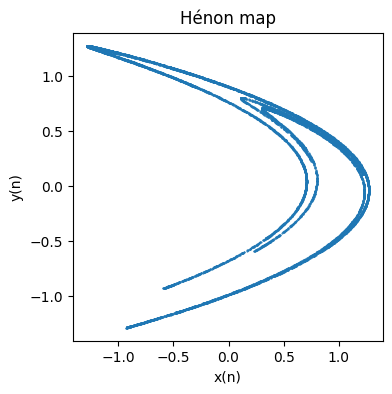

In [70]:
xs, ys = henon_map_iterations(0, 0, 10000, 200)
plt.figure(figsize=(4, 4))
plt.plot(xs, ys, '.', markersize=1)
plt.xlabel('x(n)')
plt.ylabel('y(n)')
plt.axis('equal')
plt.title('Hénon map')
plt.show()

### Calculating the largest Lyapunov exponent ($\lambda_1$)

In [71]:
def largest_lyapunov_exponent(x0, y0, r0, n_skip, n_iters, f, f_args=(), underflow=1e-20, overflow=1e6):
    # init perturbed point
    dx = r0/np.sqrt(2)
    dy = r0/np.sqrt(2)
    xp = x0 + dx
    yp = y0 + dy

    # burn-in period to get on the attractor first, while aligning the initial perturbation
    for _ in range(n_skip):
        # evolve points through the map
        x1, y1 = f(x0, y0, *f_args)
        xp1, yp1 = f(xp, yp, *f_args)

        # overflow guard
        if (not np.isfinite(x1) or not np.isfinite(y1) or
            not np.isfinite(xp1) or not np.isfinite(yp1) or
            max(abs(x1), abs(y1), abs(xp1), abs(yp1)) > overflow):
            return np.full(n_iters, np.nan)

        # project r0 onto new direction vector
        r1 = np.hypot(xp1 - x1, yp1 - y1)
        
        # underflow guard
        if r1 < underflow:
            return np.full(n_iters, np.nan)

        dx = (r0/r1) * (xp1 - x1)
        dy = (r0/r1) * (yp1 - y1)

        # get new points
        x0, y0 = x1, y1
        xp, yp = x1 + dx, y1 + dy
    
    lambda_running = np.empty(n_iters, dtype=float)
    s = 0.0
    n_valid = 0

    for i in range(n_iters):
        # evolve points through the map
        x1, y1 = f(x0, y0, *f_args)
        xp1, yp1 = f(xp, yp, *f_args)
        
        # escape/overflow guard
        if (not np.isfinite(x1) or not np.isfinite(y1) or
            not np.isfinite(xp1) or not np.isfinite(yp1) or
            max(abs(x1), abs(y1), abs(xp1), abs(yp1)) > overflow):
            lambda_running[i:] = np.nan
            break

        # project r0 onto new direction vector
        r1 = np.hypot(xp1 - x1, yp1 - y1)
        
        # underflow guard
        if r1 < underflow:
            dx = r0/np.sqrt(2)
            dy = r0/np.sqrt(2)
            # keep previous estimate to avoid log(~0)
            lambda_running[i] = lambda_running[i-1] if i > 0 else np.nan
        else:
            dx = (r0/r1) * (xp1 - x1)
            dy = (r0/r1) * (yp1 - y1)

            # update running sum of log stretch factors
            s += np.log(r1/r0)
            n_valid += 1
            lambda_running[i] = s/n_valid
        
        # get new points
        x0, y0 = x1, y1
        xp, yp = x1 + dx, y1 + dy

    return lambda_running

Estimated largest Lyapunov exponent: 0.419340


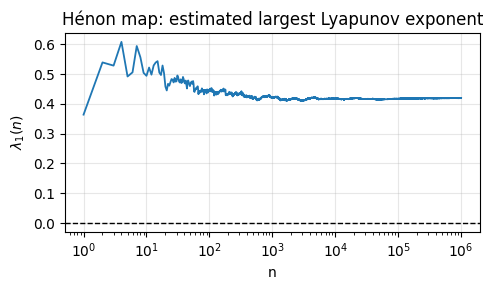

In [72]:
lam1 = largest_lyapunov_exponent(0, 0, 1e-10, 500, 1000000, henon_map)
print(f"Estimated largest Lyapunov exponent: {lam1[-1]:.6f}")

plt.figure(figsize=(5, 3))
plt.semilogx(np.arange(1, len(lam1) + 1), lam1, lw=1.3)
plt.axhline(0.0, color='k', ls='--', lw=1.0)
plt.xlabel('n')
plt.ylabel(r'$\lambda_1(n)$')
plt.title('Hénon map: estimated largest Lyapunov exponent')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Note that $\lambda_2 = \ln|b| - \lambda_1 \approx -1.623$. One can test the above procedure with multiple initial conditions within the basin of attraction to ensure validity of the convergence (as was done offline).

### Varying $a$

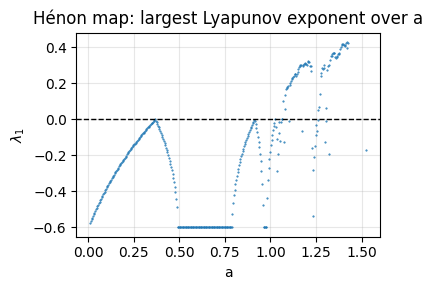

In [73]:
# lambda_1 over a
b = 0.3
a_values = np.linspace(0.01, 1.99, 500)
lam1s = np.full_like(a_values, np.nan, dtype=float)
for j, a in enumerate(a_values):
    lam1 = largest_lyapunov_exponent(
        0.0, 0.0, 1e-8, 500, 50000, henon_map, f_args=(a, b)
    )
    tail = lam1[-50:]
    tail = tail[np.isfinite(tail)]
    if tail.size > 0:
        lam1s[j] = tail.mean()
    else:
        lam1s[j] = np.nan # escape to infty

plt.figure(figsize=(4, 3))
plt.plot(a_values, lam1s, '.', markersize=1)
plt.axhline(0.0, color='k', ls='--', lw=1.0)
plt.xlabel('a')
plt.ylabel(r'$\lambda_1$')
plt.title('Hénon map: largest Lyapunov exponent over a')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As is evident above, $\lambda_1$ increasingly oscillates toward zero from negative values (signifying stable limit cycles) before the map becomes chaotic with $\lambda_1$ becoming positive after $a \approx 1.05$. There are also regions within this chaotic regime where there are stable oscillations (when $\lambda_1$ dips below zero). Otherwise, mostly, after $a \approx 1.45$ the map escapes the attractor for all empirically chosen initial conditions.

### Discovering new chaotic maps

Let
$$\begin{align*}X_{n+1} &= f(x,y) = 1-a\sin(X_n)+bY_n\tag{3}\\Y_{n+1} &= g(x, y) = X_n. \tag{4}\end{align*}$$
We can test its chaotic nature by seeing if $\lambda_1 > 0$.

In [88]:
def chaotic_map(x, y, a=1.95, b=0.3):
    x_new = 1 - (a * np.sin(x)) + (b * y)
    y_new = x
    return x_new, y_new

def chaotic_series(x0, y0, n, a=1.95, b=0.3):
    xs = [x0]
    ys = [y0]
    for _ in range(n):
        x_new, y_new = chaotic_map(xs[-1], ys[-1], a, b)
        xs.append(x_new)
        ys.append(y_new)
    return xs, ys

def chaotic_map_iterations(x0, y0, n_total, n_skip, a=1.95, b=0.3):
    xs, ys = chaotic_series(x0, y0, n_total, a=a, b=b)
    return xs[n_skip:], ys[n_skip:]

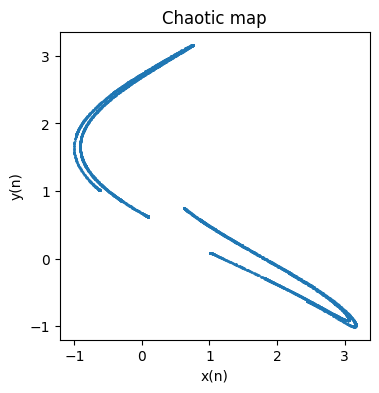

In [89]:
xs, ys = chaotic_map_iterations(0, 0, 10000, 200)
plt.figure(figsize=(4, 4))
plt.plot(xs, ys, '.', markersize=1)
plt.xlabel('x(n)')
plt.ylabel('y(n)')
plt.axis('equal')
plt.title('Chaotic map')
plt.show()

Estimated largest Lyapunov exponent: 0.219232


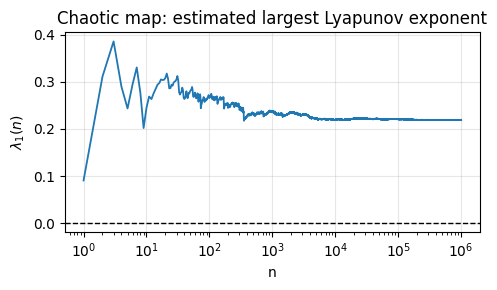

In [90]:
lam1 = largest_lyapunov_exponent(0, 0, 1e-10, 500, 1000000, chaotic_map)
print(f"Estimated largest Lyapunov exponent: {lam1[-1]:.6f}")

plt.figure(figsize=(5, 3))
plt.semilogx(np.arange(1, len(lam1) + 1), lam1, lw=1.3)
plt.axhline(0.0, color='k', ls='--', lw=1.0)
plt.xlabel('n')
plt.ylabel(r'$\lambda_1(n)$')
plt.title('Chaotic map: estimated largest Lyapunov exponent')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [91]:
# lambda_1 over a
b = 0.3
a_values = np.linspace(0.01, 1.99, 500)
lam1s = np.full_like(a_values, np.nan, dtype=float)
for j, a in enumerate(a_values):
    lam1 = largest_lyapunov_exponent(
        0.0, 0.0, 1e-8, 500, 50000, chaotic_map, f_args=(a, b)
    )
    tail = lam1[-50:]
    tail = tail[np.isfinite(tail)]
    if tail.size > 0:
        lam1s[j] = tail.mean()
    else:
        lam1s[j] = np.nan # escape to infty

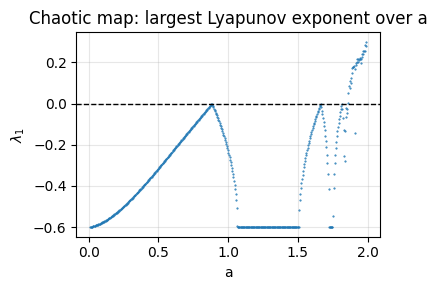

In [92]:
plt.figure(figsize=(4, 3))
plt.plot(a_values, lam1s, '.', markersize=1)
plt.axhline(0.0, color='k', ls='--', lw=1.0)
plt.xlabel('a')
plt.ylabel(r'$\lambda_1$')
plt.title('Chaotic map: largest Lyapunov exponent over a')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()